# Домашнее задание по теме «Базовые принципы ML и метрики регрессии»

Это первое домашнее задание на курсе по ML.

<!-- Повторим ключевые особенности, о которых стоит помнить (со многими из них ты уже сталкивался в рамках курса "Искуственный интеллект"): -->




Важно помнить:
* За каждую задачу ты получаешь баллы.
* Сумма баллов за все задания — 12.
Максимальный балл за домашнее задание — 10. Разница в 2 балла позволит выбирать задачи или решить все, но получить максимальный балл даже в случае ошибки.
* В заданиях будут подсказки, инструкции и дополнительная теория, которая поможет по-новому посмотреть на тему.
* Условия задач — это техническое задание для разработчика, которому надо точно следовать.



## Импорт библиотек

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#!pip install seaborn
import seaborn as sns
import time

## Загрузка данных

In [3]:
#!pip install gdown
!gdown 13vRyN_RKtoUWtGWi0O8ZlP5Q2C0O0F9l

Error:

	HTTPSConnectionPool(host='drive.google.com', port=443): Max retries
	exceeded with url: /uc?id=13vRyN_RKtoUWtGWi0O8ZlP5Q2C0O0F9l (Caused by
	SSLError(SSLCertVerificationError(1, '[SSL: CERTIFICATE_VERIFY_FAILED]
	certificate verify failed: self-signed certificate in certificate
	chain (_ssl.c:1010)')))

To report issues, please visit https://github.com/wkentaro/gdown/issues.


Дальше ты будешь работать с датасетом, который содержит данные по аренде велосипедов. Ниже подробно описаны его признаки.

In [4]:

bike = pd.read_csv('store_sharing.csv')
bike.head()

,timestamp,cnt,t1,t2,hum,wind_speed,weather_code,is_holiday,is_weekend,season
0,2015-01-04 00:00:00,182,3.0,2.0,93.0,6.0,3.0,0.0,1.0,3.0
1,2015-01-04 01:00:00,138,3.0,2.5,93.0,5.0,1.0,0.0,1.0,3.0
2,2015-01-04 02:00:00,134,2.5,2.5,96.5,0.0,1.0,0.0,1.0,3.0
3,2015-01-04 03:00:00,72,2.0,2.0,100.0,0.0,1.0,0.0,1.0,3.0
4,2015-01-04 04:00:00,47,2.0,0.0,93.0,6.5,1.0,0.0,1.0,3.0


**Признаки**

* `timestamp` — временная метка, используется для группировки данных по времени.
* `cnt` — общее количество новых аренд велосипедов (bike shares) за период между текущим и следующим `timestamp`. Обрати внимание, что это целевая переменная задачи регрессии.
* `t1` — фактическая температура воздуха (в градусах Цельсия).
* `t2` — температура «по ощущениям» (в градусах Цельсия); учитывает влияние ветра и влажности.
* `hum` — относительная влажность воздуха в процентах.
* `wind_speed` — скорость ветра (в километрах в час).
* `weather_code` — категориальный признак, описывающий погодные условия:
 * 1 — ясно;
 * 2 — рассеянная облачность / немного облаков;
 * 3 — переменная облачность (частично закрыто облаками);
 * 4 — пасмурно;
 * 7 — дождь / слабый ливень / мелкий дождь;
 * 10 — дождь с грозой;
 * 26 — снегопад;
 * 94 — туман / морозный туман.

* `is_holiday` — логический признак: 1 — праздничный день, 0 — обычный день.
* `is_weekend` — логический признак: 1 — выходной день (суббота или воскресенье), 0 — будний день.
* `season` — категориальный признак, обозначающий время года:
 * 0 — весна;
 * 1 — лето;
 * 2 — осень;
 * 3 — зима.



## Предобработка данных

Посмотрим на данные.

In [5]:
bike.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17414 entries, 0 to 17413
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   timestamp     17414 non-null  object 
 1   cnt           17414 non-null  int64  
 2   t1            17414 non-null  float64
 3   t2            17414 non-null  float64
 4   hum           17414 non-null  float64
 5   wind_speed    17414 non-null  float64
 6   weather_code  17414 non-null  float64
 7   is_holiday    17414 non-null  float64
 8   is_weekend    17414 non-null  float64
 9   season        17414 non-null  float64
dtypes: float64(8), int64(1), object(1)
memory usage: 1.3+ MB


In [6]:
bike.columns

Index(['timestamp', 'cnt', 't1', 't2', 'hum', 'wind_speed', 'weather_code',
       'is_holiday', 'is_weekend', 'season'],
      dtype='object')

In [7]:
bike.describe().T

,count,mean,std,min,25%,50%,75%,max
cnt,17414.0,1143.101642,1085.108068,0.0,257.0,844.0,1671.75,7860.0
t1,17414.0,12.468091,5.571818,-1.5,8.0,12.5,16.00,34.0
t2,17414.0,11.520836,6.615145,-6.0,6.0,12.5,16.00,34.0
hum,17414.0,72.324954,14.313186,20.5,63.0,74.5,83.00,100.0
wind_speed,17414.0,15.913063,7.894570,0.0,10.0,15.0,20.50,56.5
weather_code,17414.0,2.722752,2.341163,1.0,1.0,2.0,3.00,26.0
is_holiday,17414.0,0.022051,0.146854,0.0,0.0,0.0,0.00,1.0
is_weekend,17414.0,0.285403,0.451619,0.0,0.0,0.0,1.00,1.0
season,17414.0,1.492075,1.118911,0.0,0.0,1.0,2.00,3.0


In [8]:
# Есть ли дубли в строках

duplicate_rows = bike.duplicated().sum()
if duplicate_rows > 0:
    print("\nКоличество дублирующихся строк:", duplicate_rows)
    print("Дубли:")
    print(df[df.duplicated()])
else:
    print("\nДублирующиеся строки отсутствуют.")


Дублирующиеся строки отсутствуют.


In [9]:
# Есть ли пропущенные значения

bike.isnull().sum()

timestamp       0
cnt             0
t1              0
t2              0
hum             0
wind_speed      0
weather_code    0
is_holiday      0
is_weekend      0
season          0
dtype: int64

Проведём небольшую предобработку для более удобной работы с данными.

In [10]:
# Переименуем некоторые столбцы

bike.rename(columns={'cnt':'total_count', 't1':'temp', 't2':'feel_temp', 'hum':'humidity'}, inplace=True)
bike.columns

Index(['timestamp', 'total_count', 'temp', 'feel_temp', 'humidity',
       'wind_speed', 'weather_code', 'is_holiday', 'is_weekend', 'season'],
      dtype='object')

In [11]:
# Разделим дату и время из столбца timestamp на несколько отдельных признаков, а именно:
# год, месяц, день, день недели (номер), час

bike.timestamp = pd.to_datetime(bike.timestamp)

bike['year'] = pd.to_datetime(bike['timestamp'], format='%d/%m/%Y').dt.year
bike['month'] = pd.to_datetime(bike['timestamp'], format='%d/%m/%Y').dt.month
bike['day'] = pd.to_datetime(bike['timestamp'], format='%d/%m/%Y').dt.day
bike['day_of_week'] = pd.to_datetime(bike['timestamp'], format='%d/%m/%Y').dt.dayofweek
bike['hour'] = pd.to_datetime(bike['timestamp'], format='%d/%m/%Y').dt.hour

In [12]:
bike.head()

,timestamp,total_count,temp,feel_temp,humidity,wind_speed,weather_code,is_holiday,is_weekend,season,year,month,day,day_of_week,hour
0,2015-01-04 00:00:00,182,3.0,2.0,93.0,6.0,3.0,0.0,1.0,3.0,2015,1,4,6,0
1,2015-01-04 01:00:00,138,3.0,2.5,93.0,5.0,1.0,0.0,1.0,3.0,2015,1,4,6,1
2,2015-01-04 02:00:00,134,2.5,2.5,96.5,0.0,1.0,0.0,1.0,3.0,2015,1,4,6,2
3,2015-01-04 03:00:00,72,2.0,2.0,100.0,0.0,1.0,0.0,1.0,3.0,2015,1,4,6,3
4,2015-01-04 04:00:00,47,2.0,0.0,93.0,6.5,1.0,0.0,1.0,3.0,2015,1,4,6,4


Дальше ты будешь строить графики и делать по ним выводы. К первым задачам вывод уже написан — это поможет тебе понять, как их писать.

## Задача 1 [1 балл]

Для начала построй два графика.

1. Построй гистограмму распределения общего количества арендованных велосипедов (`total_count`) с наложенной линией KDE (Kernel Density Estimate), чтобы визуально оценить форму распределения данных. Оформи график с понятным заголовком и подписями осей. **[0,5 балла]**
  > **Примечание.** К этому графику вывод уже написан — ты найдёшь его ниже.
2. Преобразуй столбец `timestamp` к формату даты без времени (`date`). Объедини данные о прокате велосипедов по дням, посчитав суммарное количество арендованных велосипедов за каждый день. Построй линейный график с динамикой суточного числа аренд (`total_count`) во времени. Дополни график заголовком, подписью оси $Y$, а также поверни подписи по оси $X$ на 90 градусов для читаемости. **[0,5 балла]**

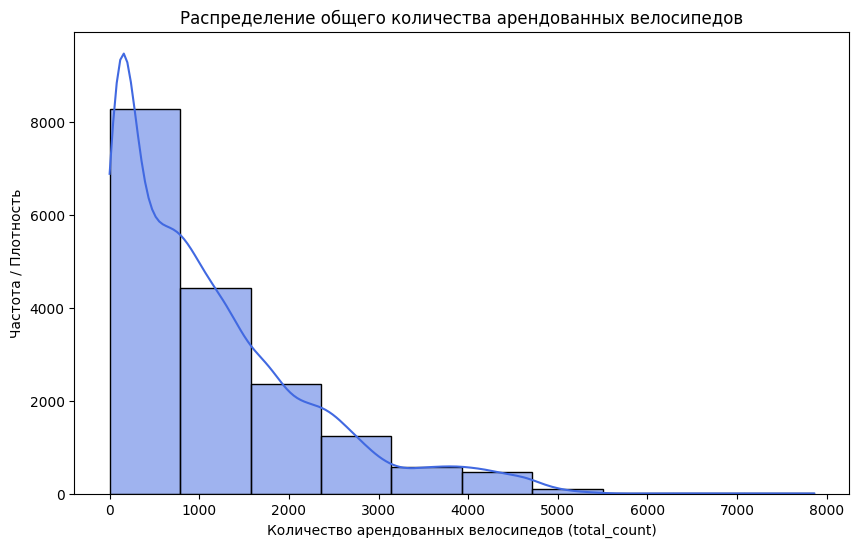

In [13]:
# Напиши здесь код для гистограммы распределения
# Создаем фигуру нужного размера
plt.figure(figsize=(10, 6))
# Строим гистограмму с линией KDE
sns.histplot(data=bike, x='total_count', kde=True, bins=10, color='royalblue')
# Добавляем подписи и заголовок
plt.title('Распределение общего количества арендованных велосипедов')
plt.xlabel('Количество арендованных велосипедов (total_count)')
plt.ylabel('Частота / Плотность')

# Отображаем график
plt.show()

**Вывод**

Гистограмма показывает распределение количества аренд велосипедов. Видна смещённость вправо. У распределения выраженная правосторонняя асимметрия — большинство значений приходится на малые значения с заметным пиком в области очень низких показателей. Это говорит о том, что чаще всего велосипеды арендуют в небольшом количестве, а случаи массового проката встречаются значительно реже.

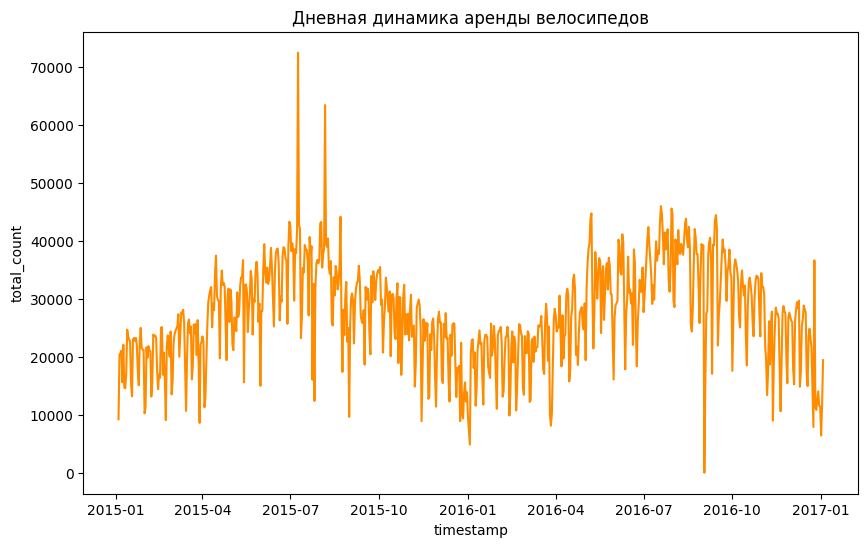

In [14]:
# Напиши здесь код для линейного графика с динамикой total_count
# Преобразуем столбец `timestamp` к формату даты без времени (`date`)
bike['timestamp'] = pd.to_datetime(bike['timestamp'])
#Объединим данные о прокате велосипедов по дням, посчитав суммарное количество арендованных велосипедов за каждый день.
daily_bike = bike.resample('D', on='timestamp')['total_count'].sum().reset_index()
# Создаем фигуру нужного размера
plt.figure(figsize=(10, 6))
# Строим линейный график
sns.lineplot(data=daily_bike, x='timestamp', y='total_count', color='darkorange')
# Добавляем подписи и заголовок
plt.title('Дневная динамика аренды велосипедов')
plt.show()


## Задача 2 [3 балла]

Продолжи и построй более сложные графики.

###Задача 2.1 [1 балл]



1. Сгруппируй данные по столбцу `month` и посчитай суммарное количество аренд велосипедов по каждому месяцу.
2. Построй линейный график с зависимостью общего количества аренд от месяца.
3. Реализуй форматирование оси $Y$ так, чтобы значения отображались в тысячах.
4. Добавь подписи осей и заголовок графика.
5. Отобрази итоговый график.

Вывод здесь тоже уже написан.



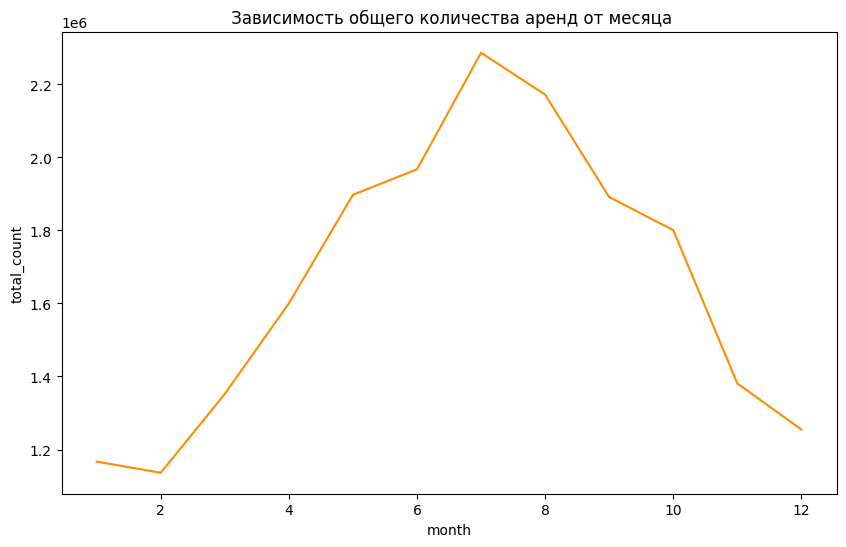

In [15]:
# Напиши здесь код для линейного графика с зависимостью общего количества аренд от месяца
# Создаем фигуру нужного размера
plt.figure(figsize=(10, 6))
monthly_bike = bike.groupby(by='month')['total_count'].sum().reset_index()
# Строим линейный график
sns.lineplot(data=monthly_bike, x='month', y='total_count', color='darkorange')
# Добавляем подписи и заголовок
plt.title(' Зависимость общего количества аренд от месяца')
plt.show()


**Вывод**

Данные показывают сезонные пики аренды велосипедов в летние месяцы (с июня по август) и спад в зимний период (с декабря по февраль). Количество аренд немного выросло с 2015 по 2016 год, но значительно снизилось в начале 2017 года. Это, вероятно, связано с внешними факторами или неполнотой данных. Использование системы велопроката зависит от тёплой погоды: летом спрос заметно выше.

###Задача 2.2 [1 балл]

1. Сгруппируй данные по сезонам и рассчитай для каждого сезона максимальное, минимальное и среднее количество аренд велосипедов с помощью функции `agg`.
2. Реализуй столбчатую диаграмму (`barplot`), которая показывает общее количество аренд велосипедов по сезонам.
3. Используй читаемые подписи сезонов вместо числовых значений (обрати внимание, как они закодированы в датасете).
4. Настрой размер графика (`figsize=(8, 4)`) и выбери цветовую палитру (`viridis`).
5. Добавь подписи осей `Season` и `Bike Shares` и заголовок графика `Total Bike Shares by Season`.
6. Отформатируй метки оси $Y$ так, чтобы значения были приведены в тысячах.
7. Выведи построенный график.

Вывод здесь уже написан.

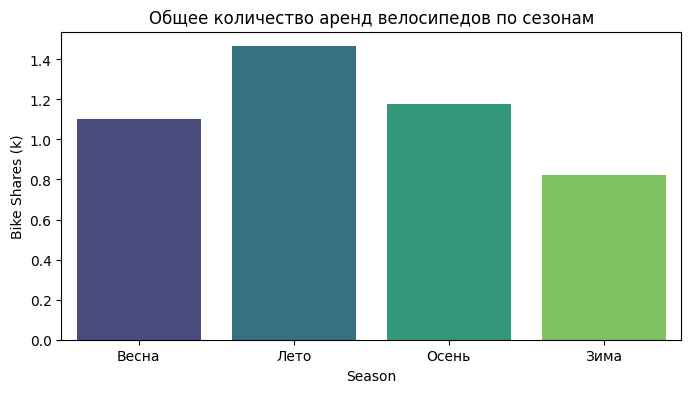

In [16]:
# Напиши здесь код для столбчатой диаграммы, показывающей общее количество аренд велосипедов по сезонам
# Создаем фигуру нужного размера
plt.figure(figsize=(8, 4))
season_bike = bike.groupby('season')['total_count'].agg(['mean']).reset_index()
# 1. Создаем словарь для декодирования сезонов
seasons_dict = {
    0.0: 'Весна',
    1.0: 'Лето',
    2.0: 'Осень',
    3.0: 'Зима'
}
season_bike['season'] = season_bike['season'].map(seasons_dict)
season_bike['mean'] = season_bike['mean'] / 1000
# Строим столбчатую диаграмму
sns.barplot(data=season_bike, x='season', y='mean', palette='viridis')
# Добавляем подписи и заголовок
plt.title('Общее количество аренд велосипедов по сезонам')
plt.xlabel('Season')
plt.ylabel('Bike Shares (k)')
plt.show()

**Вывод**

Лето и осень лидируют по количеству арендованных велосипедов. Это подкрепляет нашу гипотезу о том, что благоприятные погодные условия влияют на количество аренд.

###Задача 2.3 [1 балл]

1. Сгруппируй датафрейм `bike` по признакам `season` и `day_of_week`. Вычисли среднее значение столбца `total_count` для каждой группы и сбрось индексы.
2. Построй `pointplot`, где по оси $X$ — `day_of_week`, по оси $Y$ — `total_count`. Цветом (`hue`) обозначь сезоны, заменив числовые коды на строковые метки (как и в задаче выше).
3. Задай подписи осей и заголовок графика.
4. Обнови подписи оси $X$ так, чтобы вместо чисел отображались названия дней недели.
5. Добавь легенду графика.
6. Используй `plt.tight_layout()` для корректного размещения элементов, а затем выведи график.

Дополнительно напиши вывод по полученному графику. Можешь использовать шаблон:

* пиковая нагрузка наблюдается ... особенно с ... по ...;
* на выходных отмечается ... по сравнению с рабочей неделей;
* на графике наблюдаются сезонные колебания, они ... нашу гипотезу, обозначенную выше;
* характер поведения данных ... во все сезоны.




<Axes: xlabel='day_of_week', ylabel='total_count'>

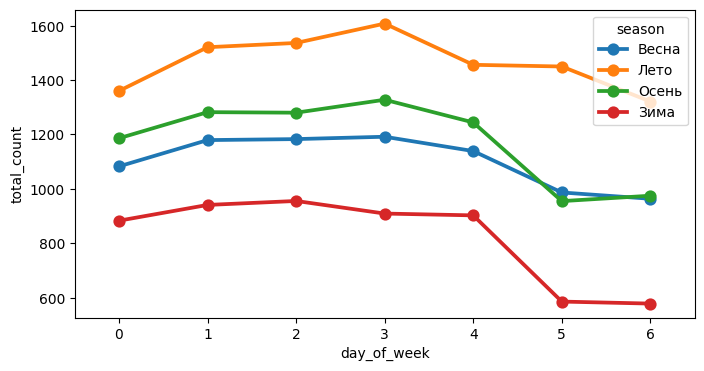

In [17]:
# Напиши код здесь для pointplot со средним количеством аренд по дням недели по сезонам
# Создаем фигуру нужного размера
plt.figure(figsize=(8, 4))
season_bike = bike.groupby(['season','day_of_week'])['total_count'].mean().reset_index()
season_bike['season'] = season_bike['season'].map(seasons_dict)
# Строим pointplot
sns.pointplot(data=season_bike, x='day_of_week', y='total_count', hue='season')

**Твой вывод**
Будние дни лидируют по количеству арендованных велосипедов во все сезоны. А летом спад происходит только в воскресенье. 

## Задача 3 [2 балла]

###Задача 3.1 [1 балл]

1. Построй линейный график, который показывает распределение количества поездок на велосипедах в зависимости от времени суток.
2. Используй признак `is_weekend` в качестве группирующего фактора, чтобы сравнить популярность велопроката в будние и выходные дни.
3. Настрой легенду так, чтобы линии были подписаны как `No` (будний день) и `Yes` (выходной день).
4. Добавь заголовок графика.
5. Отобрази график с использованием функции `plt.tight_layout()` для корректного размещения элементов.
6. Напиши вывод. Опиши наблюдения по утренним и вечерним пикам, разницу между рабочими днями и выходными.



<Axes: xlabel='hour', ylabel='total_count'>

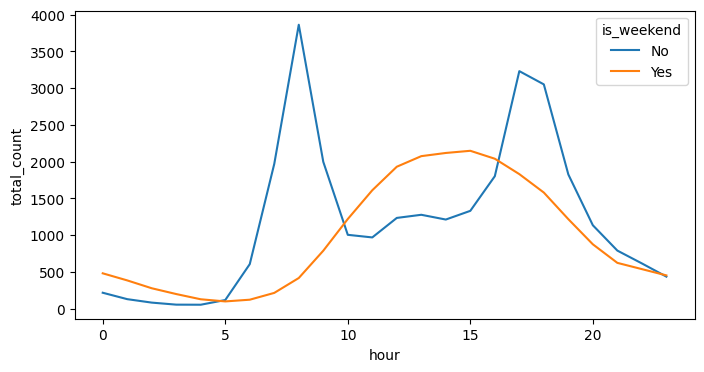

In [18]:
# Напиши здесь код для линейного графика, показывающего распределение количества поездок на велосипедах в зависимости от часа суток по будням и выходным дням
# Создаем фигуру нужного размера
plt.figure(figsize=(8, 4))
plt.tight_layout()
is_weekend_dict = {
    0.0: 'No',
    1.0: 'Yes'
}
hour_bike = bike.groupby(['hour','is_weekend'])['total_count'].mean().reset_index()
hour_bike['is_weekend'] = hour_bike['is_weekend'].map(is_weekend_dict)
# Строим lineplot
sns.lineplot(data=hour_bike, x='hour', y='total_count', hue='is_weekend')

**Твой вывод**
В будние дни сотрудники орендуют велосипеды чтобы добраться до работы утром и вернуться домой вечером
В выходные спрос на аренду растет к обеду и спадает к вечеру

###Задача 3.2 [1 балл]
1. Создай график с двумя круговыми диаграммами, расположенными в одну строку.
2. Для первой диаграммы отобрази распределение количества поездок по признаку `is_holiday` с метками `No` и `Yes`. Укажи процентное соотношение каждого значения, используй цвета `lightblue` и `orange`. Установи начальный угол (`startangle`) на 90 градусов и добавь заголовок.
3. Для второй диаграммы отобрази распределение количества поездок по признаку `is_weekend` с метками `Weekday` и `Weekend`. Укажи процентное соотношение каждого значения, используй те же цвета и начальный угол, добавь заголовок.
4. Обеспечь компактное расположение графиков с помощью tight_layout.
5. Отобрази полученный график.
6. Опиши обе круговые диаграммы. Какие выводы  можно сделать по каждой из них?


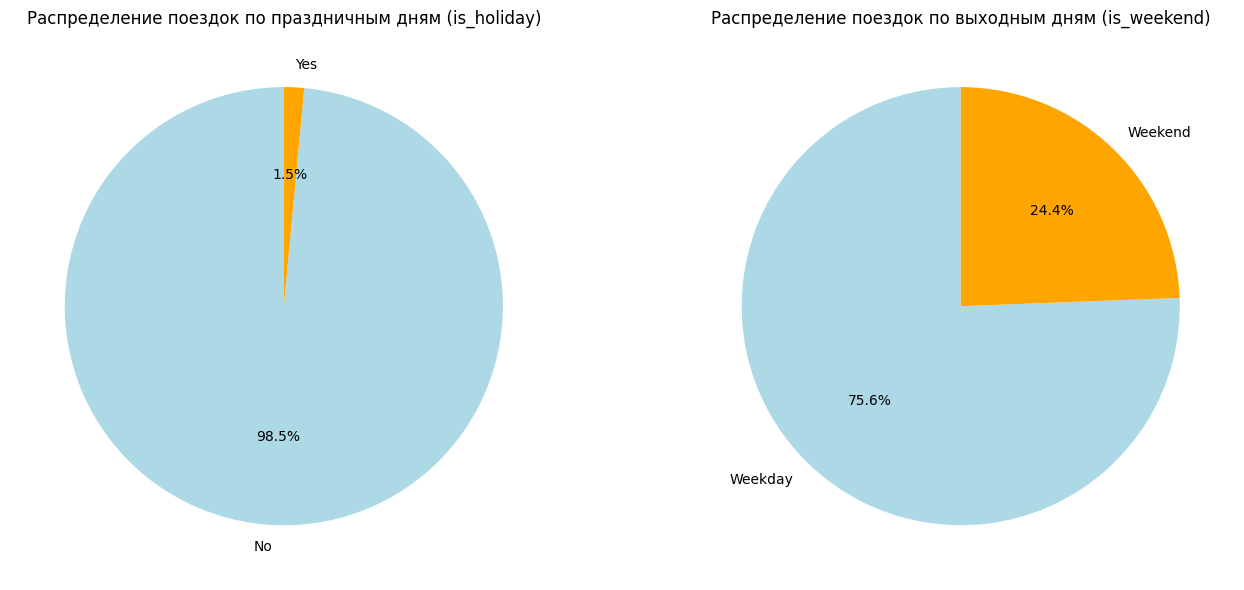

In [19]:
# Напиши здесь код для двух круговых диаграмм
holiday_bike = bike.groupby("is_holiday")["total_count"].sum()
weekend_bike = bike.groupby("is_weekend")["total_count"].sum()
fig, (holiday_ax, weekend_ax2) = plt.subplots(1, 2, figsize=(14, 6))

holiday_ax.pie(
    holiday_bike,
    labels=["No", "Yes"],
    autopct="%1.1f%%",  # отображение процентов
    colors=["lightblue", "orange"],
    startangle=90,
)
holiday_ax.set_title("Распределение поездок по праздничным дням (is_holiday)")

weekend_ax2.pie(
    weekend_bike,
    labels=["Weekday", "Weekend"],
    autopct="%1.1f%%",  # отображение процентов
    colors=["lightblue", "orange"],
    startangle=90
)
weekend_ax2.set_title("Распределение поездок по выходным дням (is_weekend)")
plt.tight_layout()
plt.show()

**Твой вывод**
Очень мало людей арендуют велосипеды по праздникам (1.5%) и почти четверть по выходным (24.4%)

## Задача 4 [3 балла]

###Задача 4.1 **[1 балл]**

1. Построй два `scatter plot` на одной фигуре с двумя строками и одним столбцом, `figsize=(15, 10)`.
2. На первом графике отобрази зависимость количества поездок на велосипедах (`total_count`) от температуры (`temp`). Обязательно добавь заголовки.
3. На втором графике отобрази зависимость количества поездок на велосипедах (`total_count`) от кода погоды (`weather_code`). Также обязательно добавь заголовки.
 * Добавь на ось $X$ второго графика метки с названиями погодных условий согласно описанию датасета.
 * Поверни подписи на 90 градусов, выровняй по центру, задай размер шрифта 10.
4. Обеспечь удобное расположение графиков с помощью `plt.tight_layout(pad=3.0)`.
5. В выводе напиши, какие закономерности ты видишь на каждом из графиков.


Text(0.5, 1.0, 'Зависимость количества поездок на велосипедах от кода погоды')

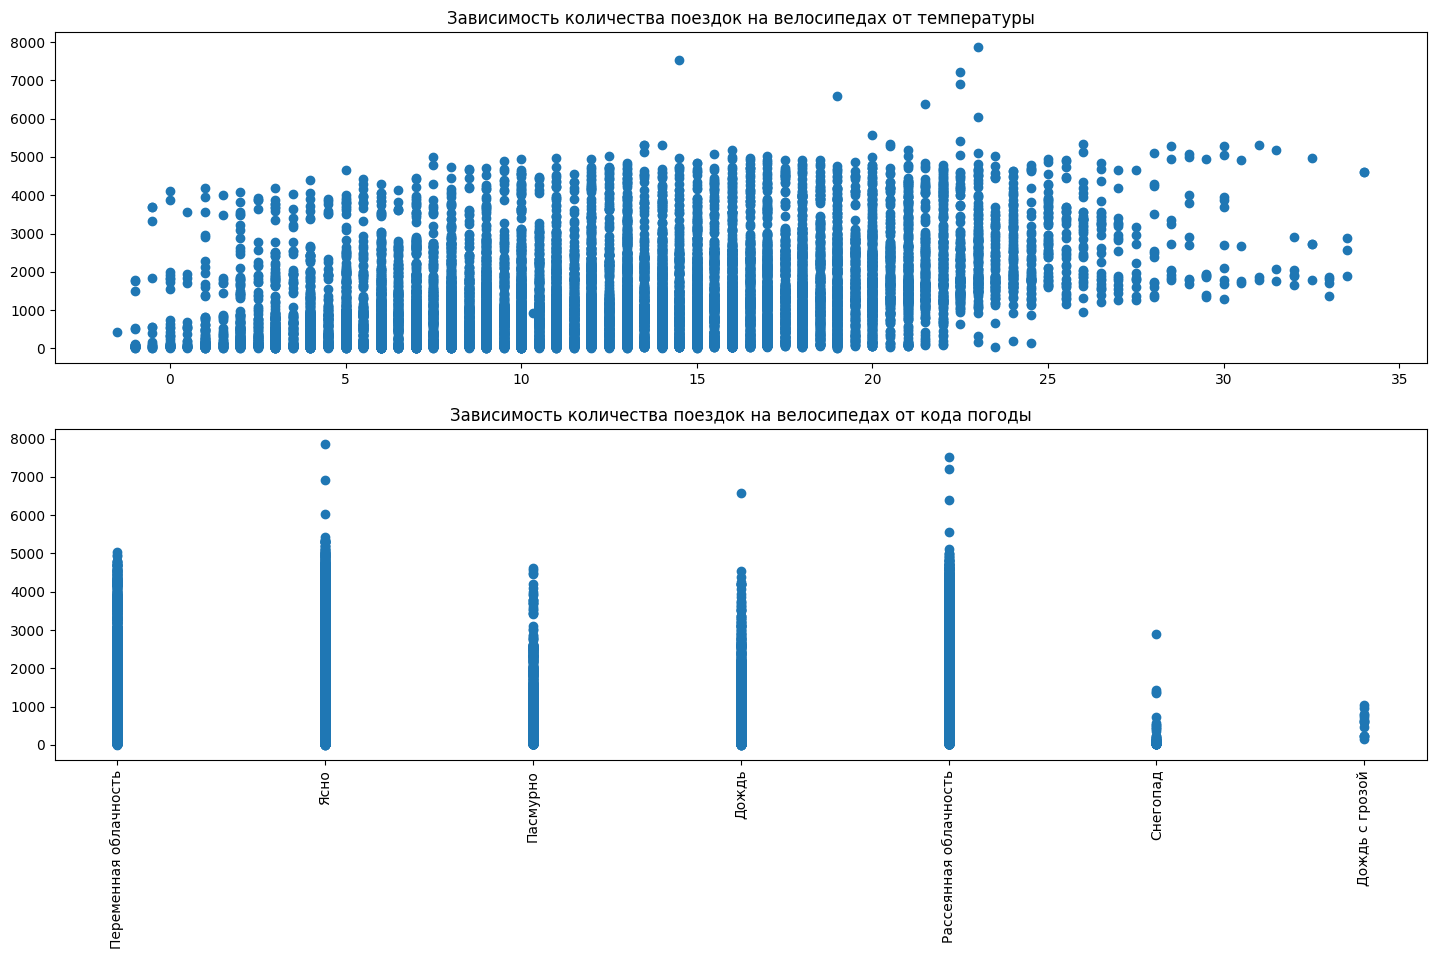

In [20]:
# Напиши здесь код для двух scatter plot
weather_dict = {
    1.0: 'Ясно',
    2.0: 'Рассеянная облачность',
    3.0: 'Переменная облачность',
    4.0: 'Пасмурно',
    7.0: 'Дождь',
    10: 'Дождь с грозой',
    26: 'Снегопад',
    94: 'Туман'
}
fig, (temp_ax, weather_ax2) = plt.subplots(2, 1, figsize=(15, 10))

temp_ax.scatter(bike["temp"], bike["total_count"])
weather_ax2.scatter(bike["weather_code"].map(weather_dict), bike["total_count"])
temp_ax.tick_params(axis='x')
weather_ax2.tick_params(axis='x', rotation=90, labelsize=10)
plt.tight_layout(pad=3.0)
temp_ax.set_title("Зависимость количества поездок на велосипедах от температуры")
weather_ax2.set_title("Зависимость количества поездок на велосипедах от кода погоды")



**Твой вывод**
В жару, холод, снег и дождь катаются мало

###Задача 4.2 [2 балла]

In [21]:
# Прежде чем перейти к следующему шагу — немного подправь данные
# Cтандартизация через StandardScaler

from sklearn.preprocessing import StandardScaler

# Возьми только числовые признаки
numerical_features = bike[['total_count', 'temp', 'feel_temp', 'humidity', 'wind_speed']]

# Инициализируй скейлер
scaler = StandardScaler()

# Примени его к числовым признакам
df_scaled = scaler.fit_transform(numerical_features)

# Переведи результат обратно в DataFrame
df_scaled = pd.DataFrame(df_scaled, columns=['total_count', 'temp', 'feel_temp', 'humidity', 'wind_speed'])

df_scaled.head()

,total_count,temp,feel_temp,humidity,wind_speed
0,-0.885745,-1.699331,-1.439290,1.444517,-1.255717
1,-0.926295,-1.699331,-1.363703,1.444517,-1.382390
2,-0.929982,-1.789071,-1.363703,1.689054,-2.015755
3,-0.987120,-1.878811,-1.439290,1.933590,-2.015755
4,-1.010160,-1.878811,-1.741635,1.444517,-1.192381




Создай финальный график.

1. Сделай расчёт корреляционной матрицы для датафрейма `df_scaled`. Построй тепловую карту (`heatmap`) этой матрицы с отображением значений корреляций, используй цветовую палитру `coolwarm`. Добавь заголовок и отобрази график.

2. Напиши подробный вывод по получившейся матрице. В первую очередь нас интересует, с чем коррелирует целевая переменная `total_count` и наибольшие значения положительной и отрицательной корреляции в матрице. Напиши минимум три пункта, которые вызывают интерес и могут быть полезны для решения задачи.



<Axes: >

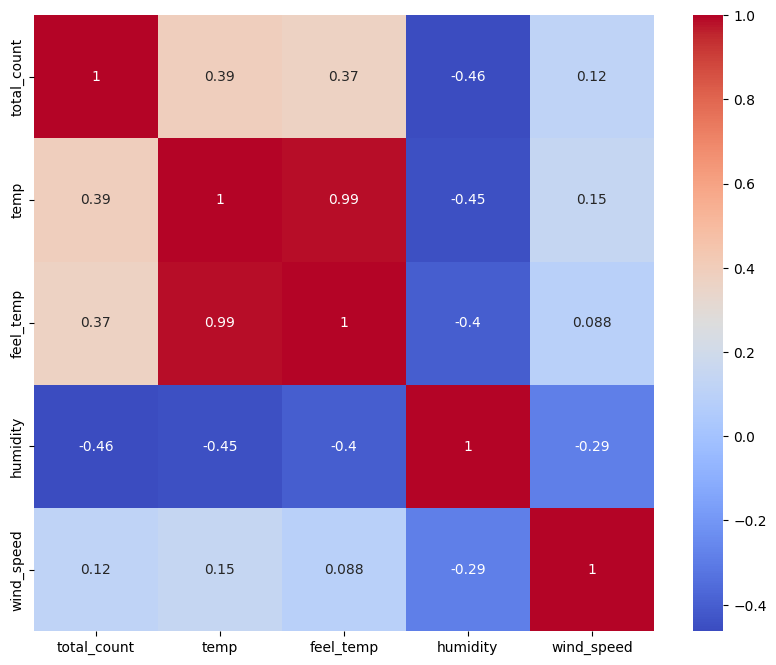

In [22]:
# Напиши код здесь — матрица корреляции

# Расчет матрицы корреляции
corr_matrix = df_scaled.corr()

# Визуализация матрицы корреляции
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')

**Твой вывод**
Больше всего переменная `total_count` коррелирует с уличной температорой
Меньше всего переменная `total_count` коррелирует с влажностью воздуха
В среднем переменная `total_count` коррелирует со скоростью ветра

## Задача 5 [3 балла]

В задаче 5 ты полностью подготовишь данные для подачи в модель: выполнишь нормализацию признаков и разделишь данные на обучающую и тестовую выборки.  

1. Обучи любую модель регрессии из библиотеки `scikit-learn`.
2. Реализуй собственные функции для расчёта коэффициента детерминации (R²) и среднеквадратичной ошибки (MSE). **[1 балл]**
3. Вычисли значения метрик с помощью своих функций и сравни их с результатами расчёта с использованием функций из `scikit-learn` (должны получиться одинаковыми).
4. Составь краткий вывод по метрикам: какие значения получились и как их можно интерпретировать с точки зрения качества модели. **[2 балла]**

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

In [24]:
X = bike.drop(['total_count','timestamp'], axis=1)
y = bike['total_count']

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = pd.concat(
    [
        pd.DataFrame(
            scaler.fit_transform(X_train[['temp', 'feel_temp', 'humidity', 'wind_speed']]),
            columns=['temp', 'feel_temp', 'humidity', 'wind_speed']
        ).reset_index(drop=True),
        X_train[['weather_code', 'is_holiday', 'is_weekend', 'season', 'year', 'month','day','day_of_week','hour']].reset_index(drop=True)
    ],
    axis=1
)
X_test_scaled = pd.concat(
    [
        pd.DataFrame(
            scaler.transform(X_test[['temp', 'feel_temp', 'humidity', 'wind_speed']]),
            columns=['temp', 'feel_temp', 'humidity', 'wind_speed']
        ).reset_index(drop=True),
        X_test[['weather_code', 'is_holiday', 'is_weekend', 'season', 'year', 'month','day','day_of_week','hour']].reset_index(drop=True)
    ],
    axis=1
)

In [27]:
# Напиши здесь код для модели, метрик и валидации

#1. Обучи любую модель регрессии из библиотеки `scikit-learn`.
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
model = LinearRegression()
model.fit(X_train, y_train)
# Предсказания и метрики
y_pred = model.predict(X_test)

# код для метрик
mse_sklearn = mean_squared_error(y_test, y_pred)
r2_sklearn = r2_score(y_test, y_pred)

# Кросс-валидация
cv_scores = cross_val_score(model, X, y, cv=5, scoring='neg_mean_squared_error')
print("CV accuracy:", cv_scores.mean(), "±", cv_scores.std())
print(f"Стандартное отклонение от среднего значения: {cv_scores.std()/abs(cv_scores.mean())*100:.0f}%")

# Сравним с наивной моделью (предсказываем среднее)
y_naive = np.full_like(y_test, np.mean(y_train))
mse_naive = mean_squared_error(y_test, y_naive)
print(f"MSE наивной модели: {mse_naive:.0f}")
print(f"MSE нашей модели:   {mse_sklearn:.0f}")
print(f"Выигрыш: {100 * (1 - mse_sklearn/mse_naive):.1f}% снижения ошибки")

CV accuracy: -841025.3305826889 ± 124964.87867585718
Стандартное отклонение от среднего значения: 15%
MSE наивной модели: 1198259
MSE нашей модели:   851080
Выигрыш: 29.0% снижения ошибки


In [28]:
#Реализуй собственные функции для расчёта коэффициента 
# детерминации (R²) и среднеквадратичной ошибки (MSE).
def r2_func(y_true, y_pred):
    return 1 - (sum((y_true - y_pred) ** 2) / sum((y_true - y_true.mean()) ** 2))

def mse_func(y_true, y_pred):
    return sum((y_true - y_pred) ** 2) / len(y_true)
#Вычисли значения метрик с помощью своих функций 
# и сравни их с результатами расчёта с использованием 
# функций из `scikit-learn` (должны получиться одинаковыми).
print("mean_squared_error=", mse_sklearn,mse_func(y_test, y_pred))
print("r2_score=", r2_sklearn, r2_func(y_test, y_pred))
#вывод: получились одинаковыми

mean_squared_error= 851079.8525821763 851079.8525821764
r2_score= 0.28972681532331857 0.28972681532331834


**Твой вывод**
Составь краткий вывод по метрикам: какие значения получились и как их можно интерпретировать с точки зрения качества модели.

При построении модели Линейной регресии получили метрики:

- Стандартное отклонение от среднего значения: 15%

- Коэффициент детерминации (R²): 29%

- Выигрыш по сравнению с наивной моделью: 29%

Интерпретация метрик:
качество модели можно считать невысоким (R² = 29% из 100%), что говорит нам о линейной модели, построенной на реальных данных с сильным шумом или нелинейными связями. Однако надо заметить, что при этом качество заметно лучше, чем у простейшей (наивной) модели. Стандартное отклонение может быть приемлимым в зависимости от постановки задачи.

Идеи на будущее:
Для улучшения качества стоит рассмотреть добавление новых признаков, учёт нелинейных зависимостей или использование более сложных моделей.